# 04. Model Evaluation and Interpretation

Notebook này dùng để đánh giá sâu mô hình tốt nhất và rút ra kết luận cuối cùng.

In [1]:
from pathlib import Path
import sys

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import Image, display

DEFAULT_ROOT = Path(r"C:\vscode\hoctap\Customer-Churn-Analysis")

def find_project_root(start_path: Path) -> Path:
    candidates = [start_path, *start_path.parents, DEFAULT_ROOT]
    for candidate in candidates:
        if (candidate / 'src').exists() and (candidate / 'configs').exists():
            return candidate
    raise FileNotFoundError('Không tìm thấy thư mục project chứa src/ và configs/.')

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data.load_data import load_dataset
from src.data.preprocess import preprocess_pipeline
from src.models.train import train_all_models
from src.models.evaluate import evaluate_models
from src.utils.config import load_project_config
from src.visualization.plots import plot_confusion_matrix, plot_feature_importance, plot_roc_curve

sns.set_theme(style='whitegrid')
config = load_project_config(PROJECT_ROOT / 'configs' / 'config.yaml')
df = load_dataset(PROJECT_ROOT / config['paths']['raw_data'])
bundle = preprocess_pipeline(df, config)
trained_models, _ = train_all_models(bundle.X_train, bundle.y_train, config)
results_df, report_map = evaluate_models(trained_models, bundle.X_test, bundle.y_test)
results_df

,model,accuracy,precision,recall,f1,roc_auc
0,adaboost,0.748048,0.517691,0.743316,0.610318,0.827383
1,teacher_voting_ensemble,0.767211,0.550439,0.671123,0.604819,0.830180
2,random_forest,0.765791,0.548246,0.668449,0.602410,0.827951
3,lightgbm,0.775018,0.568019,0.636364,0.600252,0.823057
4,xgboost,0.763662,0.544662,0.668449,0.600240,0.829439
5,gradient_boosting,0.757275,0.533333,0.684492,0.599532,0.828262
6,notebook_voting_ensemble,0.747339,0.517647,0.705882,0.597285,0.826619
7,logistic_regression,0.736693,0.502814,0.716578,0.590959,0.815531
8,decision_tree,0.751597,0.527149,0.622995,0.571078,0.797295


## 1. Chọn mô hình tốt nhất

In [2]:
best_model_name = results_df.iloc[0]['model']
best_model = trained_models[best_model_name]
comparison_subset = results_df[results_df['model'].isin([best_model_name, 'teacher_voting_ensemble', 'notebook_voting_ensemble', 'random_forest', 'xgboost', 'lightgbm'])].copy()
print('Best model:', best_model_name)
comparison_subset

Best model: adaboost


,model,accuracy,precision,recall,f1,roc_auc
0,adaboost,0.748048,0.517691,0.743316,0.610318,0.827383
1,teacher_voting_ensemble,0.767211,0.550439,0.671123,0.604819,0.830180
2,random_forest,0.765791,0.548246,0.668449,0.602410,0.827951
3,lightgbm,0.775018,0.568019,0.636364,0.600252,0.823057
4,xgboost,0.763662,0.544662,0.668449,0.600240,0.829439
6,notebook_voting_ensemble,0.747339,0.517647,0.705882,0.597285,0.826619


## 2. So sánh best model với các model mạnh khác

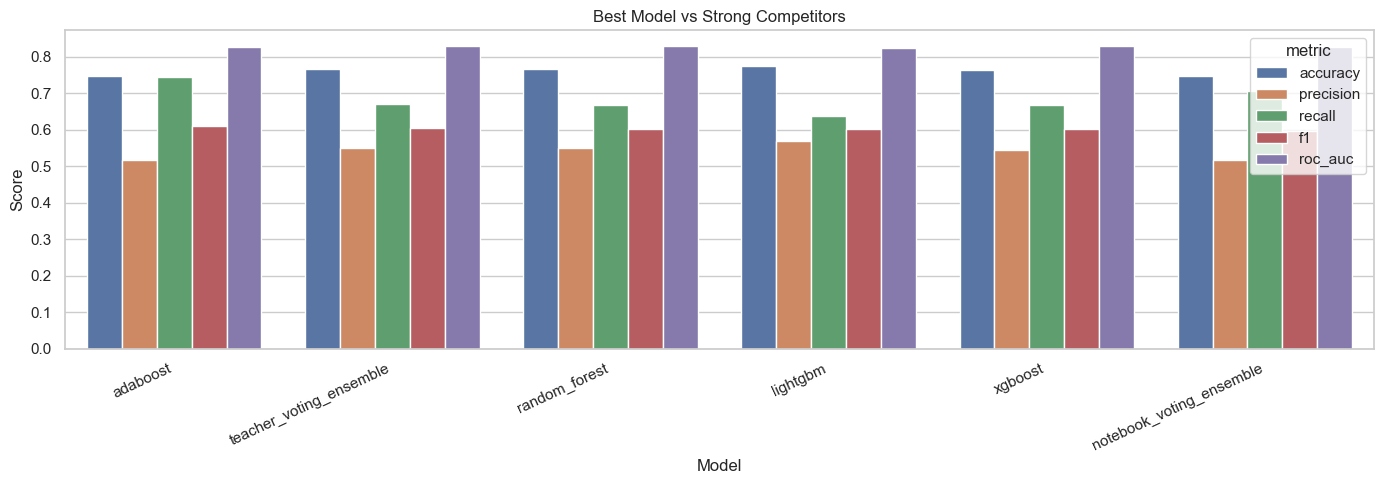

In [3]:
comparison_long = comparison_subset.melt(id_vars='model', value_vars=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'], var_name='metric', value_name='score')
plt.figure(figsize=(14, 5))
sns.barplot(data=comparison_long, x='model', y='score', hue='metric')
plt.title('Best Model vs Strong Competitors')
plt.xlabel('Model')
plt.ylabel('Score')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()

## 3. Classification report

In [4]:
print(report_map[best_model_name])

              precision    recall  f1-score   support

           0       0.89      0.75      0.81      1035
           1       0.52      0.74      0.61       374

    accuracy                           0.75      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.79      0.75      0.76      1409



## 4. So sánh phân phối dự đoán và thực tế

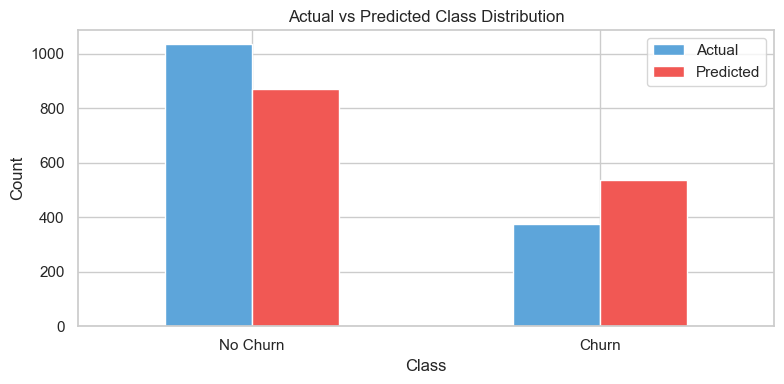

,Actual,Predicted
No Churn,1035,872
Churn,374,537


In [5]:
y_pred = best_model.predict(bundle.X_test)
distribution_df = pd.DataFrame({
    'Actual': bundle.y_test.value_counts().sort_index(),
    'Predicted': pd.Series(y_pred).value_counts().sort_index()
}).fillna(0)

distribution_df.index = distribution_df.index.map({0: 'No Churn', 1: 'Churn'})
distribution_df.plot(kind='bar', figsize=(8, 4), color=['#5DA5DA', '#F15854'])
plt.title('Actual vs Predicted Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

distribution_df

## 5. Confusion Matrix

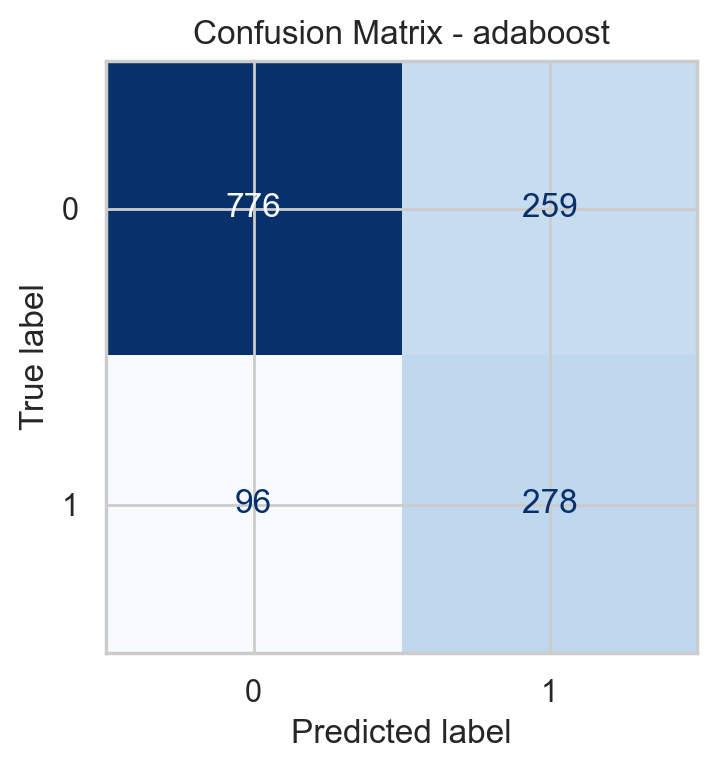

In [6]:
cm_path = PROJECT_ROOT / 'reports' / 'figures' / f'{best_model_name}_confusion_matrix_from_notebook.png'
plot_confusion_matrix(bundle.y_test, y_pred, cm_path, title=f'Confusion Matrix - {best_model_name}')
display(Image(filename=str(cm_path)))

## 6. ROC Curve

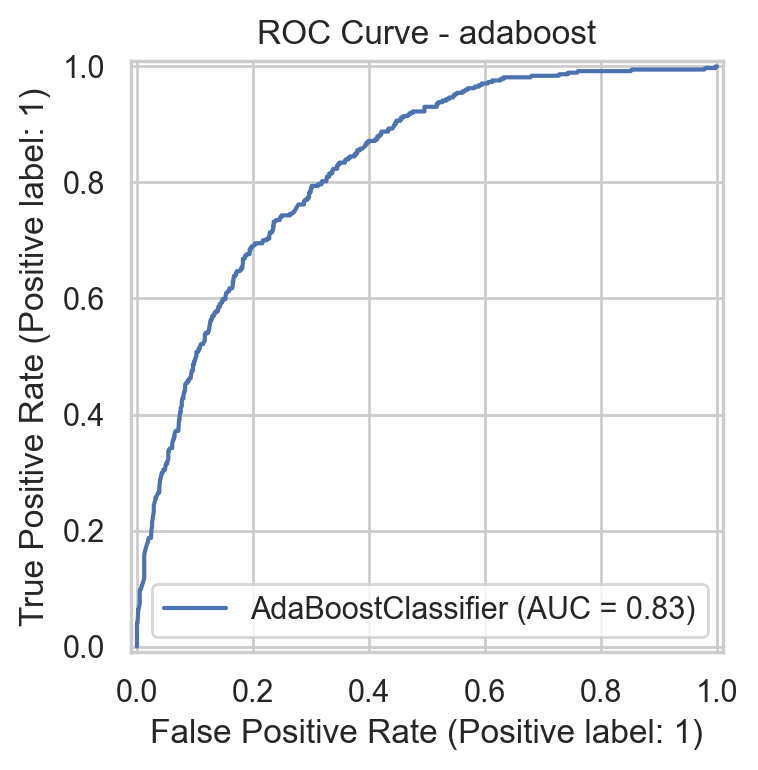

In [7]:
roc_path = PROJECT_ROOT / 'reports' / 'figures' / f'{best_model_name}_roc_curve_from_notebook.png'
plot_roc_curve(best_model, bundle.X_test, bundle.y_test, roc_path, title=f'ROC Curve - {best_model_name}')
display(Image(filename=str(roc_path)))

## 7. Feature Importance

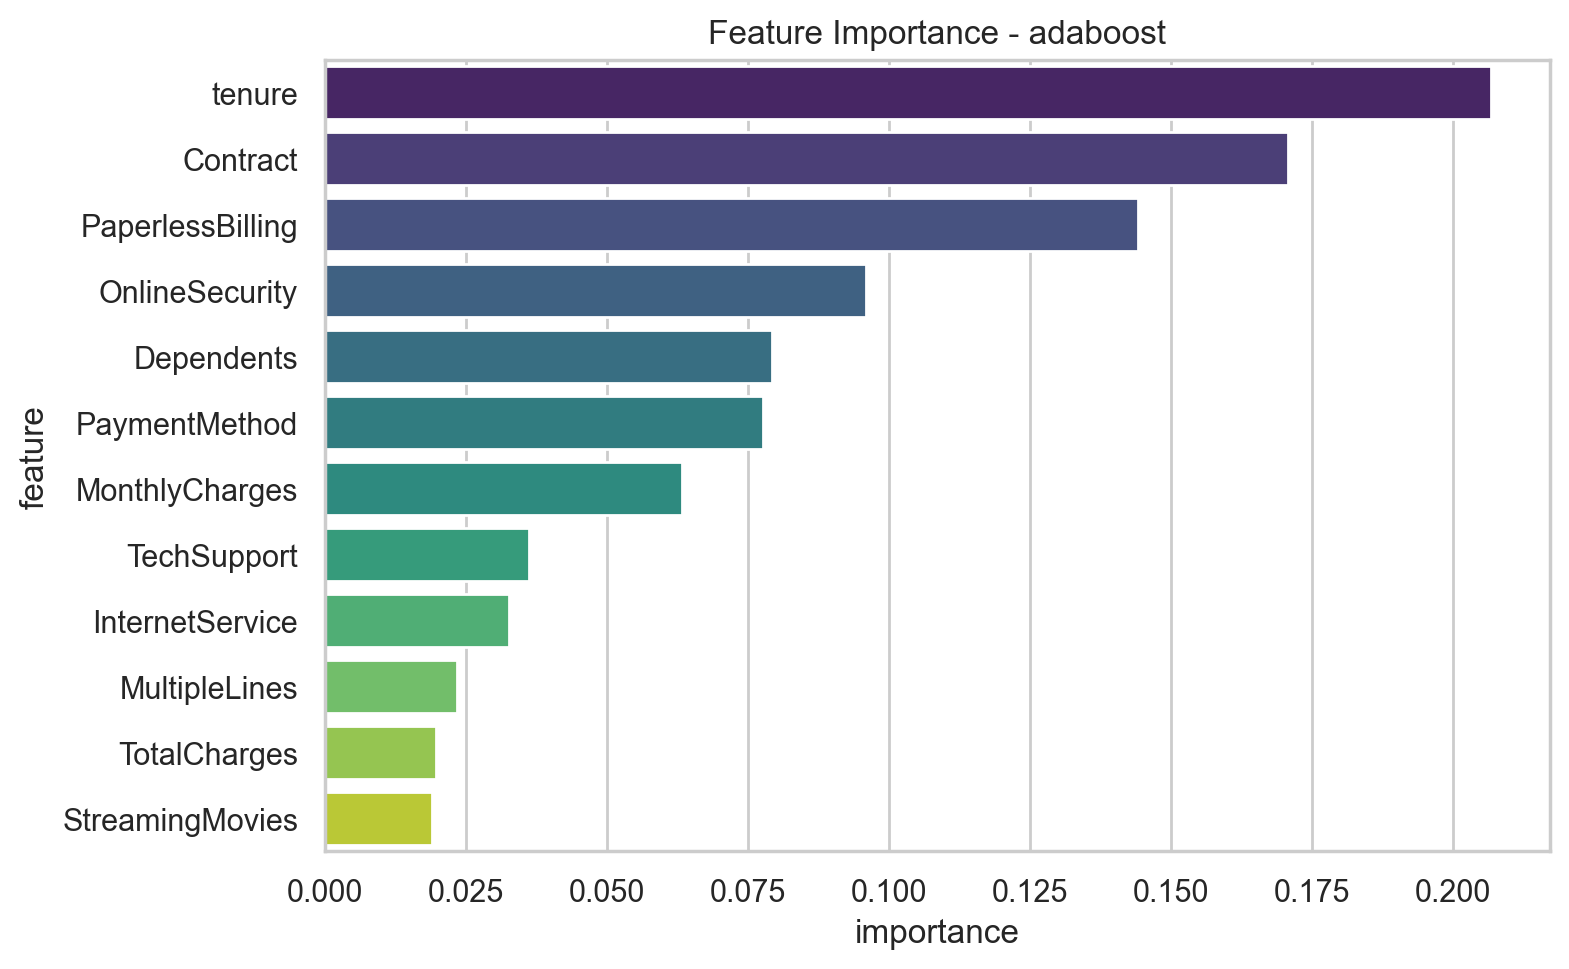

In [8]:
fi_path = PROJECT_ROOT / 'reports' / 'figures' / f'{best_model_name}_feature_importance_from_notebook.png'
plot_feature_importance(best_model, bundle.feature_names, fi_path, title=f'Feature Importance - {best_model_name}')
display(Image(filename=str(fi_path)))

## 8. Kết luận cuối cùng

In [9]:
best_row = results_df.iloc[0]
print(f"Model tốt nhất hiện tại là: {best_row['model']}")
print(f"Accuracy  : {best_row['accuracy']:.4f}")
print(f"Precision : {best_row['precision']:.4f}")
print(f"Recall    : {best_row['recall']:.4f}")
print(f"F1-score  : {best_row['f1']:.4f}")
print(f"ROC-AUC   : {best_row['roc_auc']:.4f}")

print('\nKết luận gợi ý để đưa vào báo cáo:')
print('- Mô hình tốt nhất được chọn dựa trên F1-score và các metric tổng hợp khác.')
print('- Kết quả confusion matrix cho thấy mô hình đã phân biệt khá tốt hai lớp churn và non-churn.')
print('- ROC-AUC cao cho thấy mô hình có khả năng phân tách hai lớp khá mạnh.')
print('- Feature importance giúp nhóm xác định các yếu tố ảnh hưởng nhiều nhất đến việc khách hàng rời bỏ dịch vụ.')
print('- Các yếu tố như hợp đồng, mức phí, thời gian gắn bó và dịch vụ hỗ trợ là cơ sở để đề xuất chiến lược giữ chân khách hàng.')

Model tốt nhất hiện tại là: adaboost
Accuracy  : 0.7480
Precision : 0.5177
Recall    : 0.7433
F1-score  : 0.6103
ROC-AUC   : 0.8274

Kết luận gợi ý để đưa vào báo cáo:
- Mô hình tốt nhất được chọn dựa trên F1-score và các metric tổng hợp khác.
- Kết quả confusion matrix cho thấy mô hình đã phân biệt khá tốt hai lớp churn và non-churn.
- ROC-AUC cao cho thấy mô hình có khả năng phân tách hai lớp khá mạnh.
- Feature importance giúp nhóm xác định các yếu tố ảnh hưởng nhiều nhất đến việc khách hàng rời bỏ dịch vụ.
- Các yếu tố như hợp đồng, mức phí, thời gian gắn bó và dịch vụ hỗ trợ là cơ sở để đề xuất chiến lược giữ chân khách hàng.
